In [ ]:
# Mount Drive (optional)
from google.colab import drive
import os
import shutil

# Remove existing files in the mountpoint
if os.path.exists('/content/drive'):
    shutil.rmtree('/content/drive')
    os.makedirs('/content/drive') # Recreate the directory after removing

drive.mount('/content/drive')

# Install Kaggle
!pip install kaggle

# Upload kaggle.json (download from your Kaggle account)
from google.colab import files
files.upload()  # upload kaggle.json manually

# Move it to correct place
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# 1. Illegible medical prescriptions
!kaggle datasets download -d mehaksingal/illegible-medical-prescription-images-dataset

# 2. Doctor handwriting OCR dataset
!kaggle datasets download -d bokhnhl/medical-prescription-dataset

# 3. HMP handwritten medical prescriptions
!kaggle datasets download -d chhavimohitkar/handwritten-medical-prescription-training-dataset

# 4. Synthetic medical handwriting dataset
!kaggle datasets download -d mamun1113/doctors-handwritten-prescription-bd-dataset


Dataset URL: https://www.kaggle.com/datasets/mehaksingal/illegible-medical-prescription-images-dataset
License(s): MIT
  0% 0.00/24.5M [00:00<?, ?B/s]
100% 24.5M/24.5M [00:00<00:00, 656MB/s]
Dataset URL: https://www.kaggle.com/datasets/bokhnhl/medical-prescription-dataset
License(s): unknown
  0% 0.00/87.0M [00:00<?, ?B/s]
100% 87.0M/87.0M [00:00<00:00, 914MB/s]
Dataset URL: https://www.kaggle.com/datasets/chhavimohitkar/handwritten-medical-prescription-training-dataset
License(s): MIT
  0% 0.00/20.5M [00:00<?, ?B/s]
100% 20.5M/20.5M [00:00<00:00, 379MB/s]
Dataset URL: https://www.kaggle.com/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset
License(s): ODbL-1.0
  0% 0.00/19.1M [00:00<?, ?B/s]
100% 19.1M/19.1M [00:00<00:00, 352MB/s]


extracting images

In [ ]:
import zipfile

# Define paths to the downloaded zip files
dataset_paths = [
    "/content/illegible-medical-prescription-images-dataset.zip",
    "/content/medical-prescription-dataset.zip",
    "/content/handwritten-medical-prescription-training-dataset.zip",
    "/content/doctors-handwritten-prescription-bd-dataset.zip"
]

# Unzip each dataset
for path in dataset_paths:
    with zipfile.ZipFile(path, 'r') as zip_ref:
        extract_dir = path.replace(".zip", "")
        zip_ref.extractall(extract_dir)
        print(f"Extracted {path} to {extract_dir}")



Extracted /content/illegible-medical-prescription-images-dataset.zip to /content/illegible-medical-prescription-images-dataset
Extracted /content/medical-prescription-dataset.zip to /content/medical-prescription-dataset
Extracted /content/handwritten-medical-prescription-training-dataset.zip to /content/handwritten-medical-prescription-training-dataset
Extracted /content/doctors-handwritten-prescription-bd-dataset.zip to /content/doctors-handwritten-prescription-bd-dataset


Found 129 images


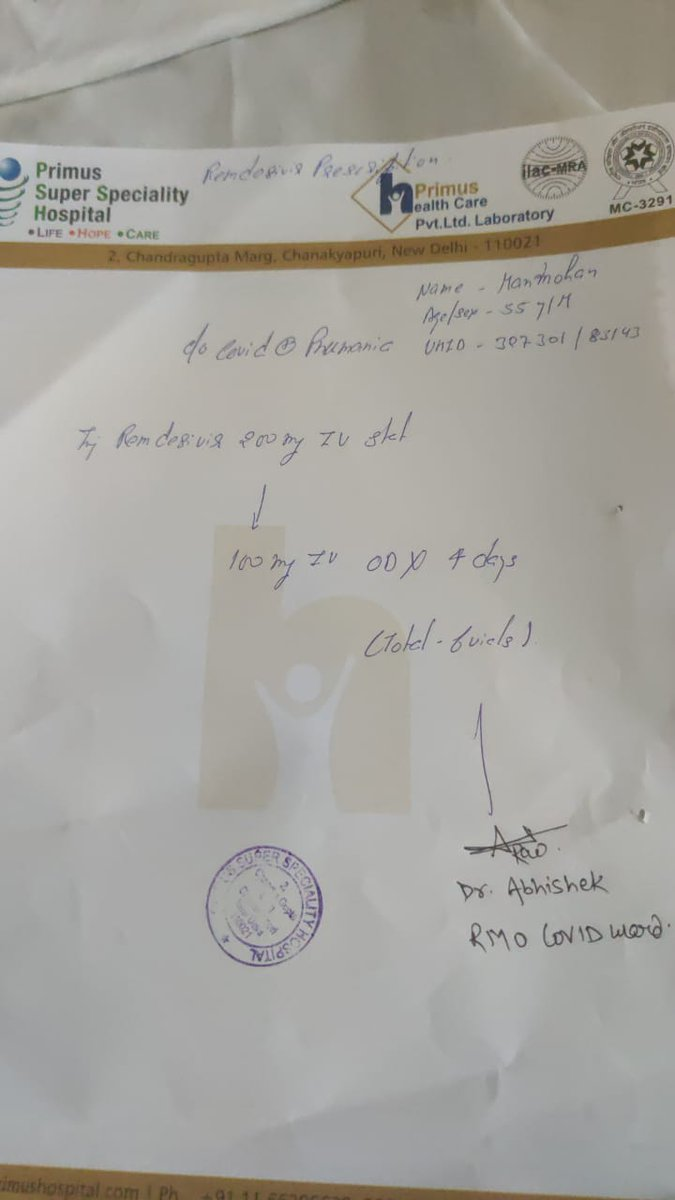

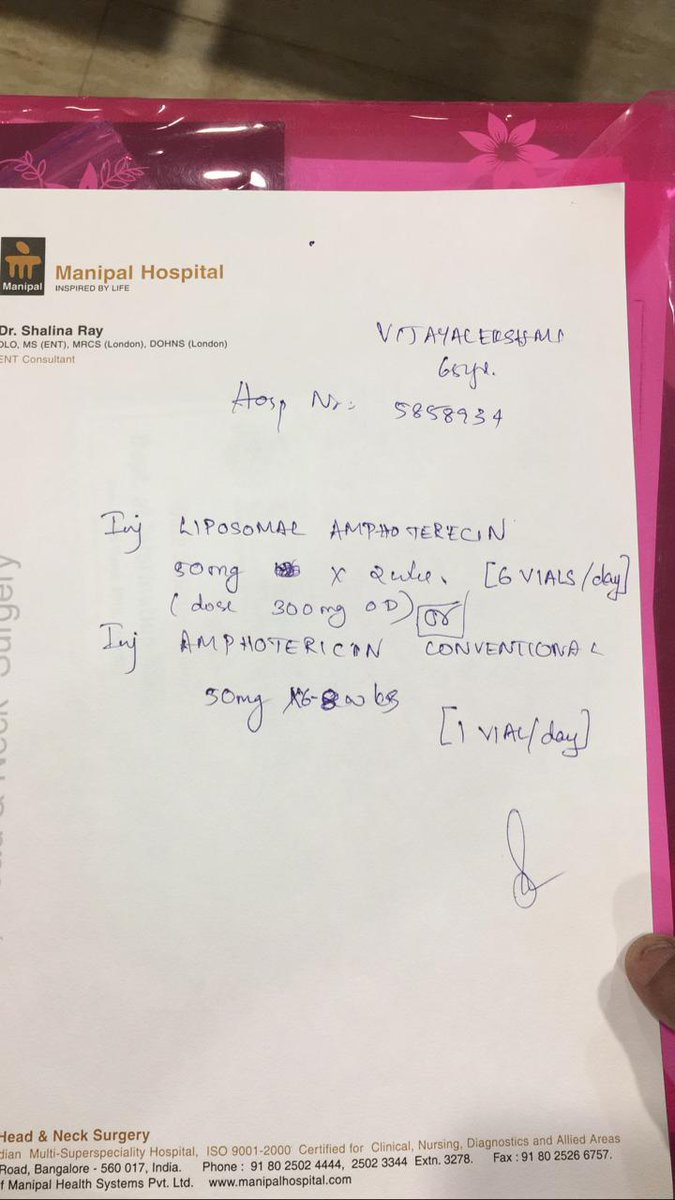

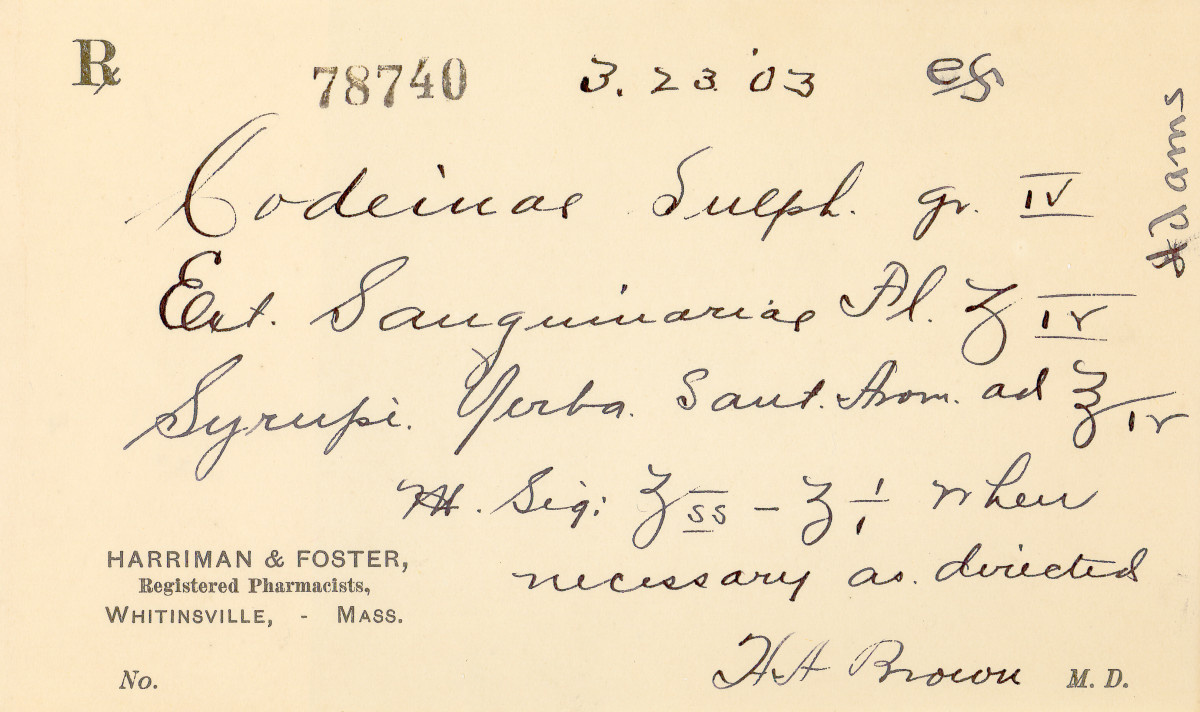

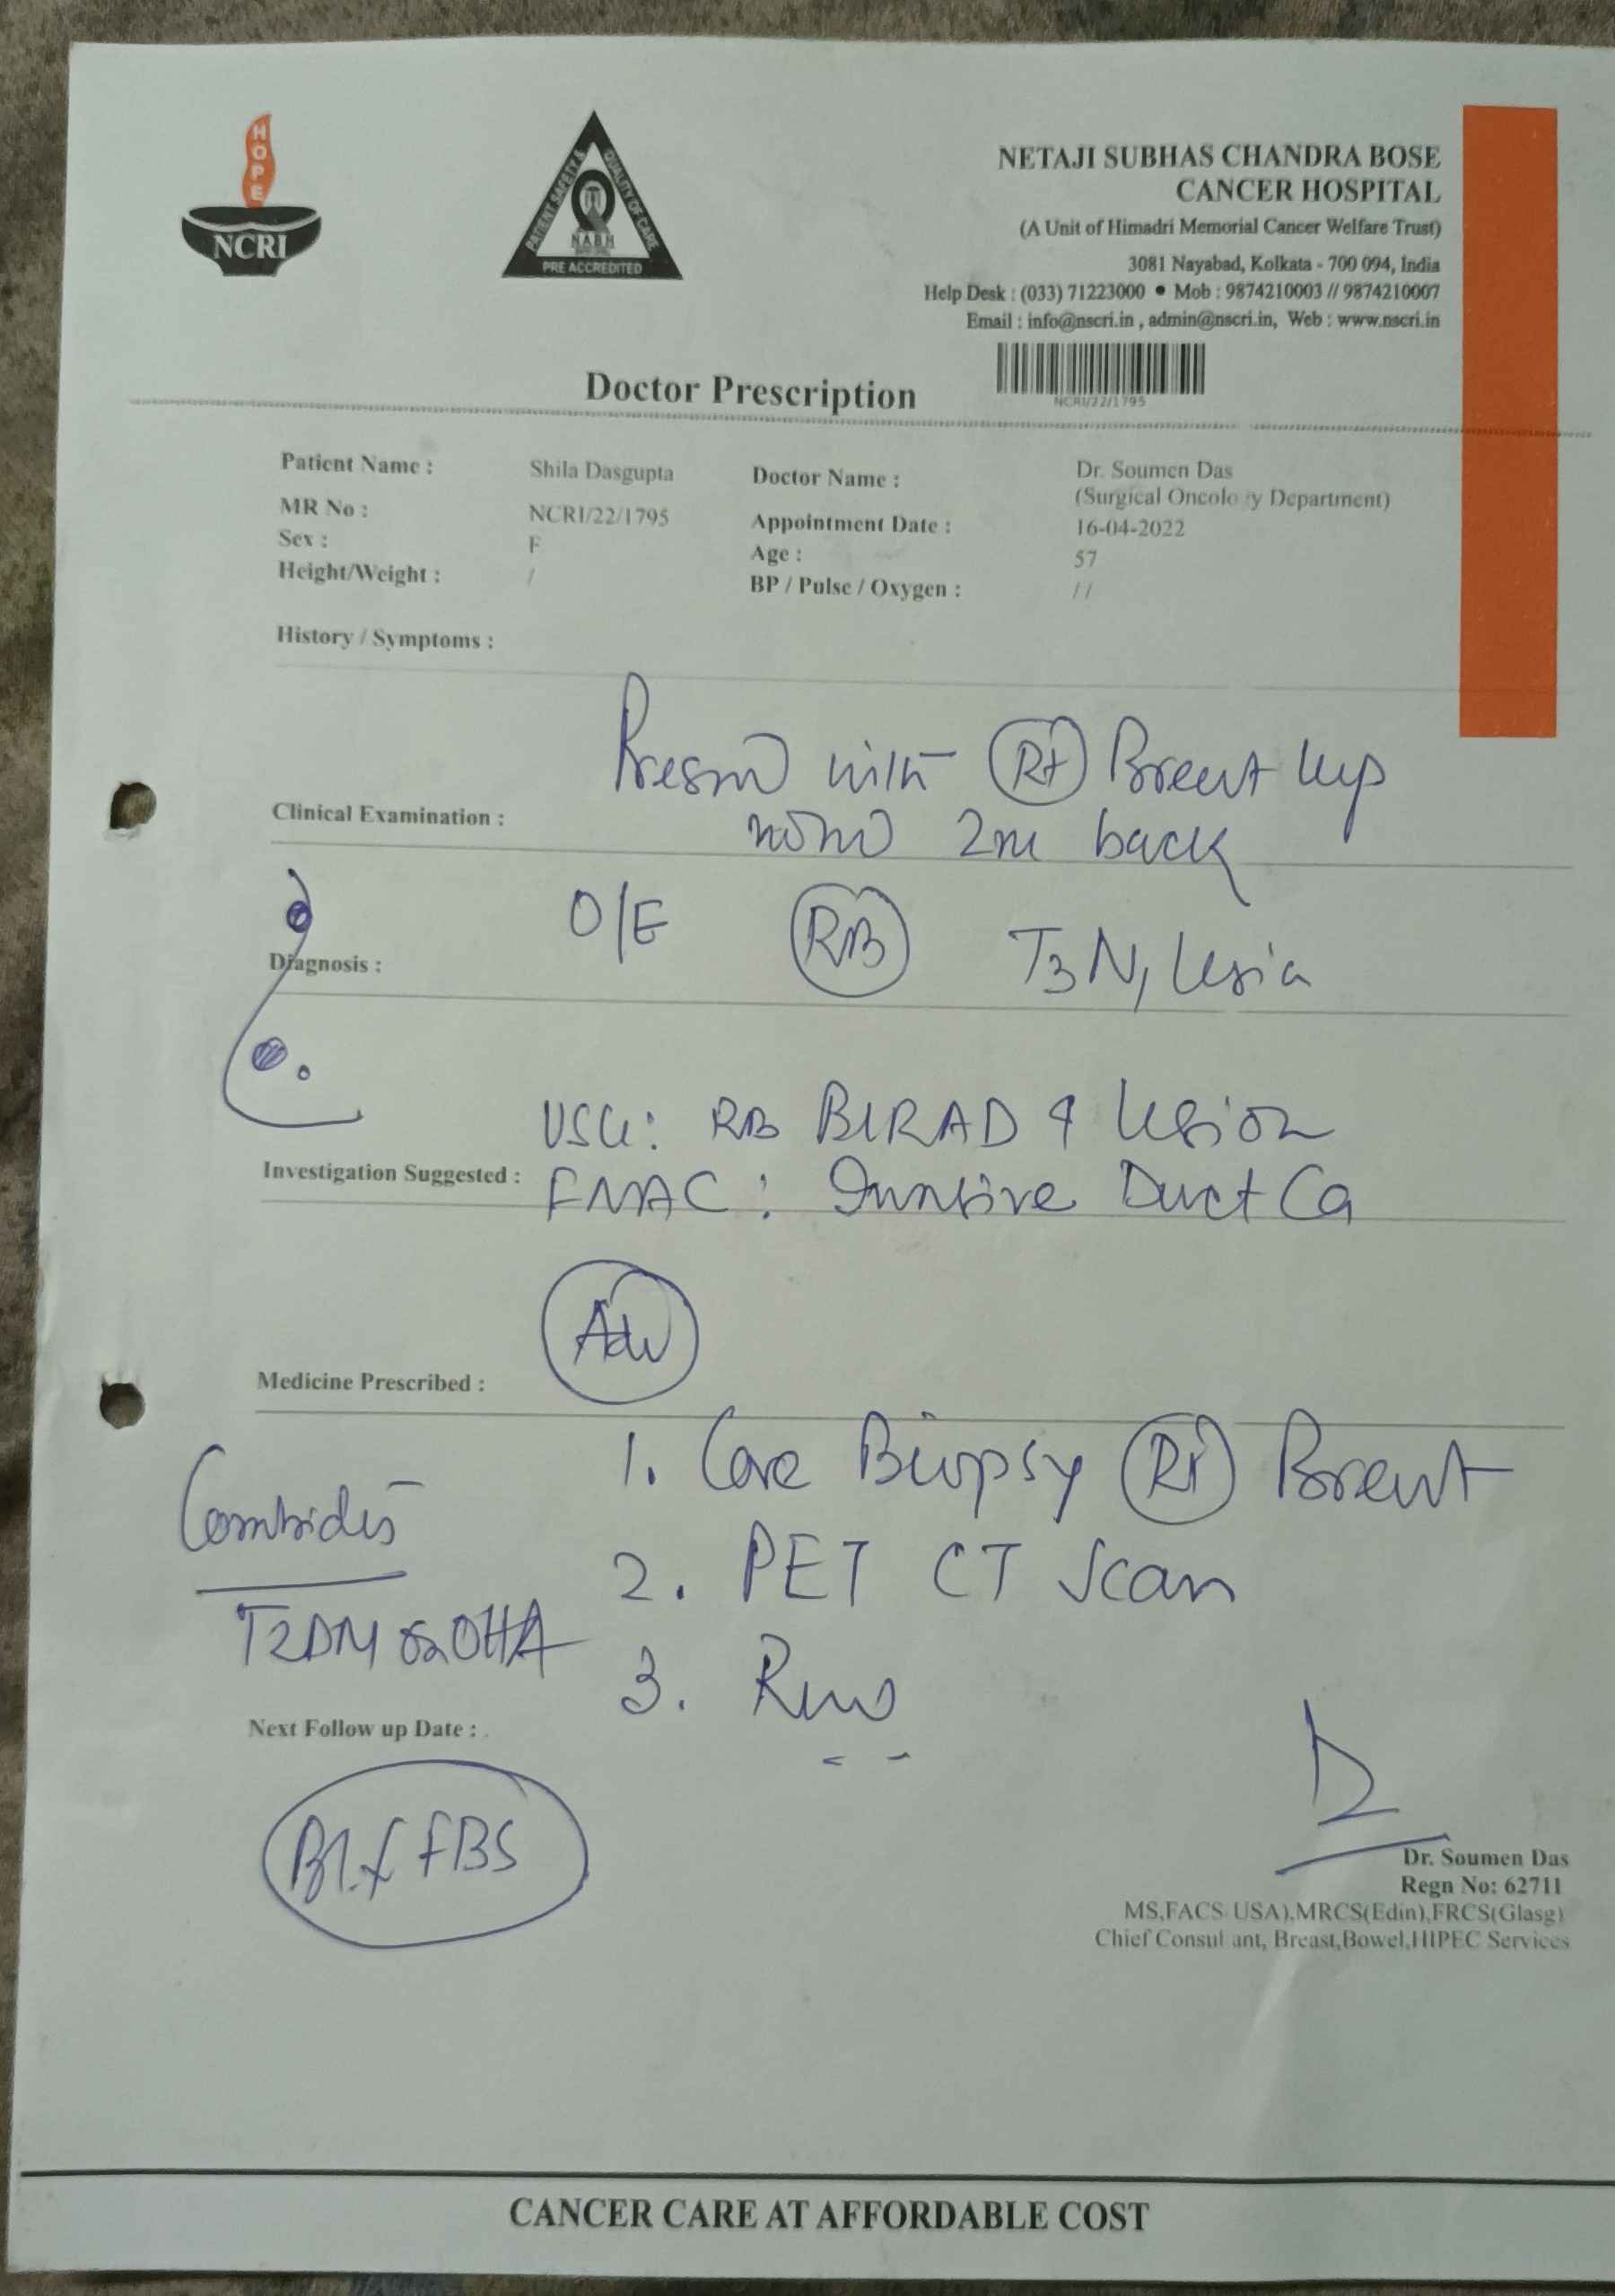

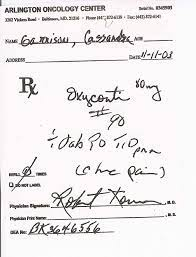

In [ ]:
import os
from glob import glob
from IPython.display import Image, display

# Example: explore first dataset
dataset_dir = "/content/illegible-medical-prescription-images-dataset"
all_images = glob(os.path.join(dataset_dir, "**/*.jpg"), recursive=True)
print(f"Found {len(all_images)} images")

# Display a few sample images
for img_path in all_images[:5]:
    display(Image(filename=img_path))


In [ ]:
import os, zipfile

# Base folder for all datasets
base_dir = '/content/drive/MyDrive/MedSign/data'
os.makedirs(base_dir, exist_ok=True)

# List of downloaded zip files
datasets = [
    'illegible-medical-prescription-images-dataset.zip',
    'medical-prescription-dataset.zip',
    'handwritten-medical-prescription-training-dataset.zip',
    'doctors-handwritten-prescription-bd-dataset.zip'
]

# Extract each dataset
for data in datasets:
    zip_path = f'/content/{data}'
    extract_folder = os.path.join(base_dir, data.replace('.zip', ''))
    os.makedirs(extract_folder, exist_ok=True)
    if os.path.exists(zip_path):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_folder)
            print(f"✅ Extracted {data} to {extract_folder}")
    else:
        print(f"⚠️ File {data} not found. Make sure it downloaded successfully.")


✅ Extracted illegible-medical-prescription-images-dataset.zip to /content/drive/MyDrive/MedSign/data/illegible-medical-prescription-images-dataset
✅ Extracted medical-prescription-dataset.zip to /content/drive/MyDrive/MedSign/data/medical-prescription-dataset
✅ Extracted handwritten-medical-prescription-training-dataset.zip to /content/drive/MyDrive/MedSign/data/handwritten-medical-prescription-training-dataset
✅ Extracted doctors-handwritten-prescription-bd-dataset.zip to /content/drive/MyDrive/MedSign/data/doctors-handwritten-prescription-bd-dataset


In [ ]:
import shutil

merged_folder = '/content/drive/MyDrive/MedSign/merged_images'
os.makedirs(merged_folder, exist_ok=True)

image_exts = ('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')

copied = 0
for root, dirs, files in os.walk(base_dir):
    for f in files:
        if f.lower().endswith(image_exts):
            src = os.path.join(root, f)
            dst = os.path.join(merged_folder, f"{copied}_{f}")
            shutil.copy2(src, dst)
            copied += 1

print(f"✅ Copied {copied} images to {merged_folder}")


✅ Copied 5253 images to /content/drive/MyDrive/MedSign/merged_images


In [ ]:
import cv2
from tqdm import tqdm

processed_folder = '/content/drive/MyDrive/MedSign/processed_images'
os.makedirs(processed_folder, exist_ok=True)

IMG_SIZE = (224, 224)

count = 0
for img_name in tqdm(os.listdir(merged_folder)):
    try:
        img_path = os.path.join(merged_folder, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, IMG_SIZE)
        save_path = os.path.join(processed_folder, img_name)
        cv2.imwrite(save_path, img)
        count += 1
    except Exception as e:
        print(f"⚠️ Error processing {img_name}: {e}")

print(f"✅ Preprocessing complete — {count} images saved to {processed_folder}")


100%|██████████| 9289/9289 [38:53<00:00,  3.98it/s]

✅ Preprocessing complete — 9289 images saved to /content/drive/MyDrive/MedSign/processed_images


In [ ]:
!sudo apt install -y tesseract-ocr
!pip install pytesseract

import pytesseract
import pandas as pd

image_files = [f for f in os.listdir(processed_folder) if f.lower().endswith(image_exts)]
output_csv = '/content/drive/MyDrive/MedSign/digitized_prescriptions.csv'
data = []

for f in tqdm(image_files):
    img_path = os.path.join(processed_folder, f)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    text = pytesseract.image_to_string(img, lang='eng').strip()
    data.append({'Image_Name': f, 'Extracted_Text': text})

df = pd.DataFrame(data)
df.to_csv(output_csv, index=False)
print(f"✅ OCR complete — CSV saved at {output_csv}")


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


100%|██████████| 9289/9289 [20:53<00:00,  7.41it/s]


✅ OCR complete — CSV saved at /content/drive/MyDrive/MedSign/digitized_prescriptions.csv


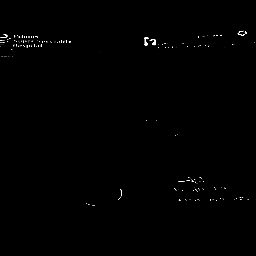

In [ ]:
from google.colab.patches import cv2_imshow

preprocessed_img = preprocess_image(all_images[0])
cv2_imshow(preprocessed_img)